<h1 dir=rtl align=center style="line-height:200%;font-family:vazirmatn;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
سیمان بازی
</font>
</h1>

<h2 dir=rtl align=right style="line-height:200%;font-family:vazirmatn;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مقدمه و صورت مسئله
</font>
</h2>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazirmatn; font-size:medium">
<font face="vazirmatn">
این مجموعه داده شامل فرمولاسیون‌های مختلف سیمان و مقاومت فشاری متناظر با آن‌هاست. هدف این بخش، پیش‌بینی مقاومت بتن بر اساس مواد اولیه و زمان عمل‌آوری آن است. با تحلیل این ویژگی‌ها، شما یک مدل برای پیش‌بینی دقیق مقاومت نهایی سیمان توسعه خواهید داد. هدف شما پیاده نمودن یک مدل رگرسیونی است.
</font>
</p>

<h2 dir=rtl align=right style="line-height:200%;font-family:vazirmatn;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
معرفی مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazirmatn; font-size:medium">
<font face="vazirmatn" size=3>
در فایل اولیه‌ی این سوال، یک پوشه با نام <code>Data</code> وجود دارد که شامل ۲ فایل <code>train.csv</code> و <code>test.csv</code>.
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazirmatn; font-size:medium">
<font face="vazirmatn" size=3>

</font>
</p>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazirmatn; font-size:medium">
<font face="vazirmatn" size=3>
هرستون این مجموعه‌داده با توجه به ماهیت خود می‌تواند مقادیر عددی یا رشته‌ای داشته باشد. برای آشنایی بیشتر با مجموعه‌داده، پیشنهاد می‌شود هرستون به صورت جداگانه بررسی شود.</font>
</p>

<h4 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معرفی مجموعه داده آموزشی (train.csv)
</font>
</h4>

<div dir="rtl">
<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>

فایل <code>train.csv</code> دارای `824` سطر و `12` ستون می‌باشد که ستون‌های آن به شرح زیر می‌باشد:

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    

| نام ستون | توضیح |
|:---: |:---: |
| `Cement ` | مقدار سیمان بر حسب کیلوگرم بر متر مکعب. سیمان ماده اصلی چسبنده در بتن است و مقدار آن مستقیماً با مقاومت نهایی مرتبط است.|
| `Blast Furn Slag` | مقدار سرباره کوره بلند بر حسب کیلوگرم بر متر مکعب. این ماده یک افزودنی سیمانی است که مقاومت بتن، به ویژه در بلندمدت، را افزایش می‌دهد.|
| `Fly Ash` |مقدار خاکستر بادی بر حسب کیلوگرم بر متر مکعب. این ماده افزودنی، که محصول جانبی احتراق زغال سنگ است، به بهبود کارایی و مقاومت بتن کمک می‌کند.|
| `Water ` | مقدار آب بر حسب کیلوگرم بر متر مکعب.|
| `Superplas` | مقدار فوق روان کننده بر حسب کیلوگرم بر متر مکعب.|
| `Coarse Ag` |مقدار سنگدانه درشت (شن یا سنگ خرد شده) بر حسب کیلوگرم بر متر مکعب.ی |
| `Fine Aggre` | مقدار سنگدانه ریز (ماسه) بر حسب کیلوگرم بر متر مکعب. این ماده فضاهای خالی بین سنگدانه‌های درشت را پر کرده و به صافی و تراکم بتن می‌افزاید.|
| `Age` | سن بتن در زمان آزمایش بر حسب روز.|
| `cement per water` |این ستون نسبت سیمان به آب را نشان می‌دهد.|
| `Cement Impurity Factor` |معیاری برای ناخالصی‌های موجود در سیمان را نشان می‌دهد.|
| `Cement Moisture Factor` |میزان رطوبت موجود در سیمان باشد. رطوبت سیمان می‌تواند بر نسبت مؤثر آب به سیمان و در نتیجه بر مقاومت بتن تأثیر بگذارد.|
| `Strength` |این متغیر هدف است که باید آن را پیش‌بینی کنید. این ستون مقاومت فشاری بتن را بر حسب مگاپاسکال نمایش می‌دهد.|


</font>
</div>
</center>
</div>

In [169]:
# TODO:
import numpy as np
import pandas as pd
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from torch import optim

df = pd.read_csv('Data/train.csv')
test_data = pd.read_csv('Data/test.csv')

In [170]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,cement per water,Cement Impurity Factor,Cement Moisture Factor,Strength
0,310.0,0.0,0.0,192.0,0.0,970.0,850.0,7,1.614583,-1.494973,NaN,14.99
1,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,56,1.978576,14.926196,1.978576,72.99
2,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,2.198908,7.749160,NaN,35.30
3,439.0,177.0,0.0,186.0,11.1,884.9,707.9,91,2.360215,5.005339,2.360215,73.30
4,136.0,162.0,126.0,172.0,10.0,923.0,764.0,28,0.790698,8.589054,0.790698,29.07


In [171]:
df.shape

(824, 12)

In [172]:
test_data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,cement per water,Cement Impurity Factor,Cement Moisture Factor
0,266.0,114.0,0.0,228.0,0.0,932.0,670.0,365,1.166667,14.818225,1.166667
1,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,2.198908,-0.595567,NaN
2,389.9,189.0,0.0,145.9,22.0,944.7,755.8,28,2.672378,-6.266026,2.672378
3,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,2.198908,-4.238082,NaN
4,145.0,0.0,179.0,202.0,8.0,824.0,869.0,28,0.717822,-3.571469,NaN


In [173]:
test_data.shape

(206, 11)

<h2 dir=rtl align=right style="line-height:200%;font-family:vazirmatn;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
پیش‌پردازش و مهندسی ویژگی
</font>
</h2>

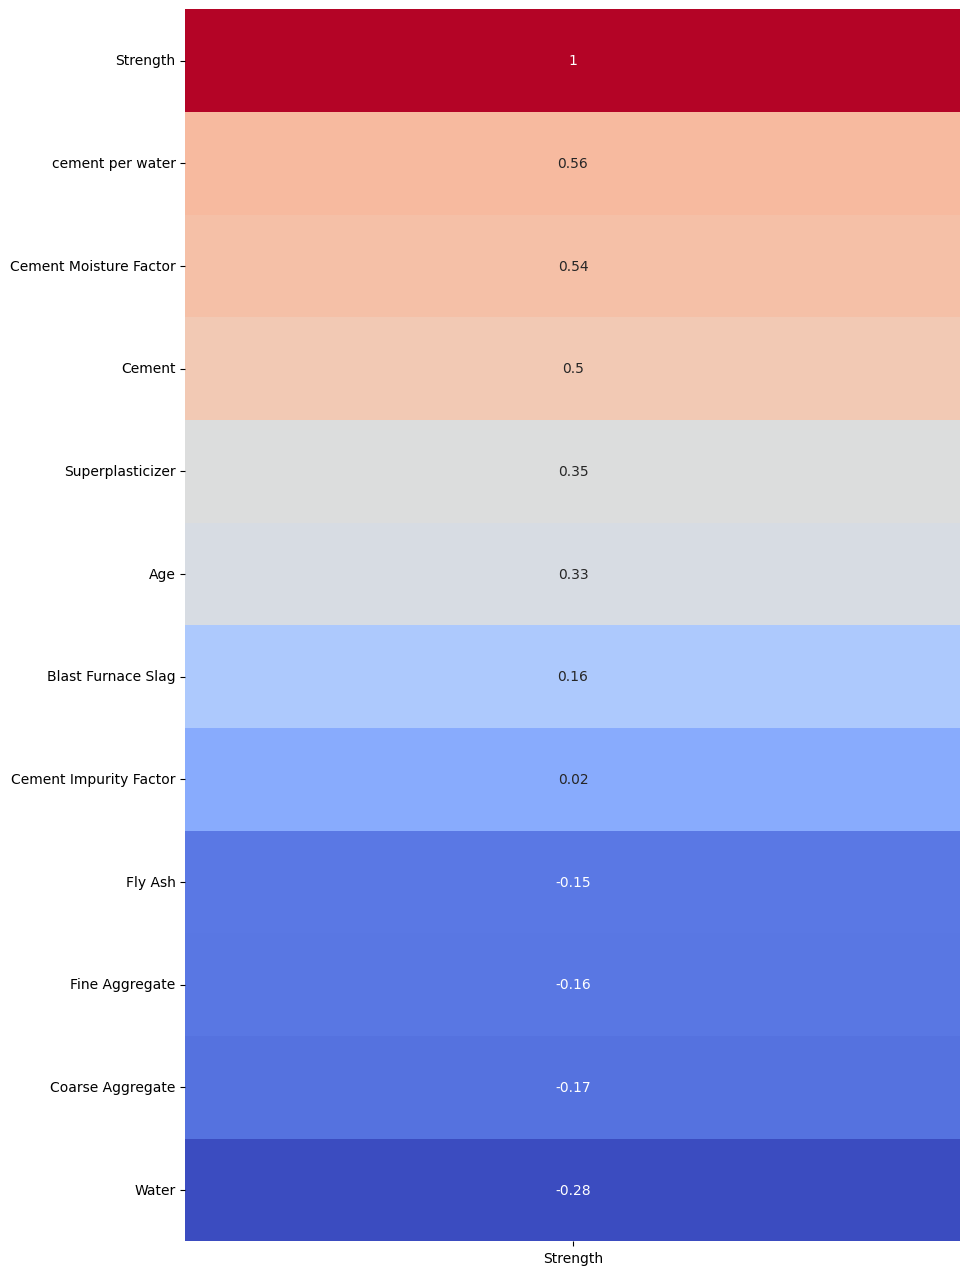

In [174]:
# TODO:
corr = df.corr()['Strength'].sort_values(ascending = False)
plt.figure(figsize = (10, 16))
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.show()

In [175]:
df.isnull().sum()

Cement                      0
Blast Furnace Slag          0
Fly Ash                     0
Water                       0
Superplasticizer            0
Coarse Aggregate            0
Fine Aggregate              0
Age                         0
cement per water            0
Cement Impurity Factor      0
Cement Moisture Factor    460
Strength                    0
dtype: int64

In [176]:
new_df = df[df['Cement Moisture Factor'].notna()]
goal = df[df['Cement Moisture Factor'].isna()]
goal.shape

(460, 12)

In [177]:
x = new_df.drop(['Cement Moisture Factor'], axis = 1)
y = new_df['Cement Moisture Factor']

In [178]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = .15)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((309, 11), (55, 11), (309,), (55,))

In [179]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

## Using K_NN to replace nan with predicted values

In [180]:
class KNNRegressor:
    def __init__(self, k=3, distance_func=None, weights='uniform'):
        self.k = k
        self.weights = weights
        self.distance_func = distance_func or self._euclidean_distance

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y, dtype=float)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        X = np.asarray(X)
        predictions = []

        for x in X:
            distances = np.array(
                [self.distance_func(x, x_train) for x_train in self.X_train]
            )

            k_indices = np.argsort(distances)[:self.k]
            k_values = self.y_train[k_indices]

            if self.weights == 'distance':
                k_distances = distances[k_indices]
                k_distances[k_distances == 0] = 1e-8
                weights = 1 / k_distances
                pred = np.sum(weights * k_values) / np.sum(weights)
            else:
                pred = np.mean(k_values)

            predictions.append(pred)

        return np.array(predictions)


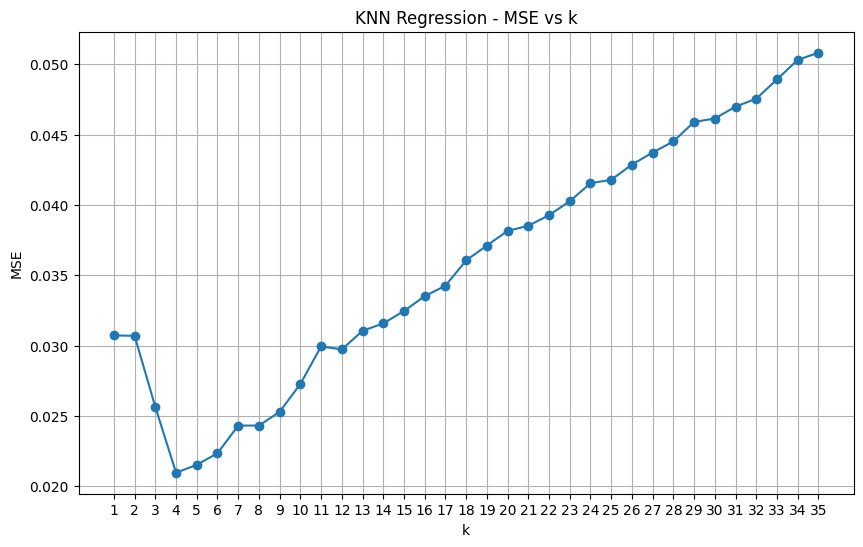

In [181]:
from sklearn.metrics import mean_squared_error

k_values = range(1, 36)
mse_scores = []

for k in k_values:
    knn = KNNRegressor(k=k, weights='distance')
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)

plt.figure(figsize=(10,6))
plt.plot(k_values, mse_scores, marker='o')
plt.xlabel('k')
plt.ylabel('MSE')
plt.title('KNN Regression - MSE vs k')
plt.xticks(k_values)
plt.grid(True)
plt.show()


# k = 4 is an excellent hyperparameters

In [182]:
knn = KNNRegressor(k=4, weights='distance')
knn.fit(x_train_scaled, y_train)
mask = df['Cement Moisture Factor'].isna()
X_nan = df.loc[mask].drop('Cement Moisture Factor', axis=1)
df.loc[mask, 'Cement Moisture Factor'] = knn.predict(X_nan)

In [183]:
df.isnull().sum()

Cement                    0
Blast Furnace Slag        0
Fly Ash                   0
Water                     0
Superplasticizer          0
Coarse Aggregate          0
Fine Aggregate            0
Age                       0
cement per water          0
Cement Impurity Factor    0
Cement Moisture Factor    0
Strength                  0
dtype: int64

In [184]:
df.shape

(824, 12)

In [185]:
df.drop_duplicates(inplace = True)

In [186]:
df.shape

(824, 12)

<h2 dir=rtl align=right style="line-height:200%;font-family:vazirmatn;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
آموزش مدل
</font>
</h2>


In [187]:
# TODO:
x = df.drop(['Strength'], axis = 1)
y = df['Strength']

In [188]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = .15)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((700, 11), (124, 11), (700,), (124,))

In [189]:
x_scale = StandardScaler()
y_scale = StandardScaler()

x_train_scaled = x_scale.fit_transform(x_train)
x_test_scaled = x_scale.transform(x_test)

y_train_scaled = y_scale.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scale.transform(y_test.values.reshape(-1, 1))

In [190]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [191]:
x_train_scaled_tensor = torch.tensor(x_train_scaled,device = device, dtype= torch.float32 )
x_test_scaled_tensor = torch.tensor(x_test_scaled,device = device, dtype= torch.float32 )
y_train_scaled_tensor = torch.tensor(y_train_scaled,device = device, dtype= torch.float32 )
y_test_scaled_tensor = torch.tensor(y_test_scaled,device = device, dtype= torch.float32 )

# Model Architecture

In [192]:
class manualRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(11, 4)
        self.fc2 = nn.Linear(4, 2)
        self.fc3 = nn.Linear(2, 1)
        self.relu = nn.ReLU()
        self.Dropout = nn.Dropout(.005)

    def forward(self, x):
        x = self.Dropout(self.relu(self.fc1(x)))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x


In [193]:
torch.manual_seed(42)
model = manualRegression().to(device)

In [194]:
train_losses = []
test_losses = []
epochs = 0

100 : 0.18066014349460602  test : 0.1798994541168213
200 : 0.14223457872867584  test : 0.1615283191204071
300 : 0.13780593872070312  test : 0.14893747866153717
400 : 0.1332622766494751  test : 0.1429983526468277
500 : 0.15506531298160553  test : 0.14584378898143768
600 : 0.12688428163528442  test : 0.13779735565185547


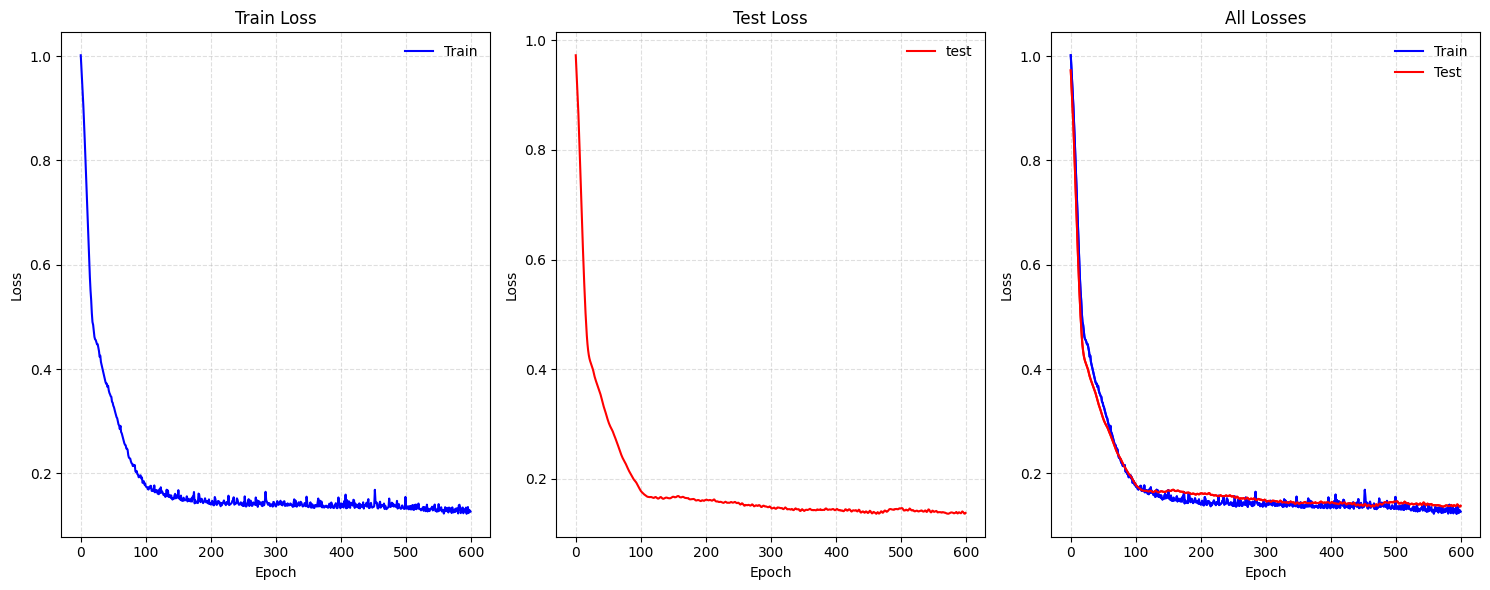

In [195]:
loss_fn = nn.MSELoss()
lr = .01
epoch = 600
optimizer = optim.Adam(model.parameters(), lr = lr)
epochs = epochs + epoch
for i in range(epoch):
    model.train()
    y_pred = model(x_train_scaled_tensor)
    loss = loss_fn(y_pred, y_train_scaled_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.detach().cpu().item())

    model.eval()
    with torch.no_grad():
        y_pred_test = model(x_test_scaled_tensor)
        loss_test = loss_fn(y_test_scaled_tensor, y_pred_test)
        test_losses.append(loss_test.detach().cpu().item())
    if (i + 1) % 100 == 0:
        print(f"{i+1} : {loss.item()}  test : {loss_test.item()}") 
fig, axes = plt.subplots(1, 3, figsize = (15, 6))

axes[0].plot(range(epochs), train_losses, c="blue" , label = "Train" )
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(loc = "upper right" , frameon = False)
axes[0].grid(True , linestyle = "--" , alpha = .4)

axes[1].plot(range(epochs), test_losses, c="red" , label = "test" )
axes[1].set_title("Test Loss")
axes[1].legend(loc = "upper right" , frameon = False)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True , linestyle = "--" , alpha = .4)

axes[2].plot(range(epochs) , train_losses , c = "blue" , label = "Train" )
axes[2].plot(range(epochs) , test_losses , c = "red" , label = "Test" )
axes[2].legend(frameon = False , loc = "upper right")
axes[2].set_title("All Losses")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(True , linestyle = "--" , alpha = .4)
plt.plot(range(epochs) , train_losses, c = 'blue', label = 'train')
plt.plot(range(epochs) , test_losses, c = 'red', label = 'val')

plt.tight_layout()
plt.show()

<h2 dir=rtl align=right style="line-height:200%;font-family:vazirmatn;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
معیار ارزیابی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazirmatn; font-size:medium">
<font face="vazirmatn" size=3>
    معیاری که برای ارزیابی عملکرد مدل انتخاب کرده‌ایم، <code>r2_score</code> نام دارد.
    <br>
    این معیار، سنجه ارزیابی کیفیت مدل شماست. به عبارت بهتر در سامانه داوری هم از همین معیار برای نمره‌دهی استفاده شده است.
    <br>
    پیشنهاد می‌شود با توجه به این معیار، عملکرد مدل خود را بر روی مجموعه‌ی آموزش یا اعتبارسنجی ارزیابی کنید.
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazirmatn; font-size:medium">
<font color="red"><b color='red'>توجه:</b></font>
<font face="vazirmatn" size=3>
    برای دریافت نمره از این سوال لازم است تا دقت مدل شما از آستانه‌ی ۰.۶ بیشتر باشد.
    در صورتی که دقت مدل شما از ۰.۶ کمتر باشد نمره شما 
    <b>صفر</b>خواهد بود.
</font>
</p>

In [196]:
with torch.no_grad():
    y_pred = model(x_test_scaled_tensor)

y_pred = y_pred.detach().cpu().numpy()
y_pred = y_scale.inverse_transform(y_pred)
y_test = y_test_scaled_tensor.detach().cpu().numpy()
y_test = y_scale.inverse_transform(y_test)

print(f'MAE = {mean_absolute_error(y_pred, y_test)}')
print(f'MAPE = {mean_absolute_percentage_error(y_pred, y_test)}')
print(f'MSE = {mean_squared_error(y_pred, y_test)}')
print(f'RMSE = {mean_squared_error(y_pred, y_test) ** .5}')
print(f'R2 = {r2_score(y_pred, y_test)}')

MAE = 4.824563503265381
MAPE = 0.15163485705852509
MSE = 39.1356086730957
RMSE = 6.255845959827951
R2 = 0.8396168947219849


In [197]:
x_test_data = x_scale.transform(test_data)
x_test_ten = torch.tensor(x_test_data, device = device, dtype = torch.float32)

In [198]:
with torch.no_grad():
    y_pred = model(x_test_ten).detach().cpu().numpy()

y_pred = y_scale.inverse_transform(y_pred)
submission = pd.DataFrame(y_pred, columns = ['Strength'])
submission.head()

,Strength
0,39.578625
1,NaN
2,67.992401
3,NaN
4,NaN


In [168]:
# test_data.isnull().sum()
submission.isnull().sum()

Strength    106
dtype: int64